# Harreman + Vision on single-cell (non-spatial) data

This notebook demonstrates that Harreman's `ha.hs` gene-module analysis
**covers Hotspot's functionality** and, together with `ha.vs` (VISION signature
autocorrelation), is **applicable beyond spatial transcriptomics** — both run
here on a standard droplet scRNA-seq dataset with no physical coordinates at
all, using a PCA embedding as the neighbor graph instead.

**Dataset:** a mouse bone-marrow hematopoiesis scRNA-seq dataset (the same one
bundled with the R `VISION` package's own basic-usage vignette), 4,763 cells
across 7 sorted cell-type populations (erythrocytes, granulocytes, monocytes,
lymphocytes, dendritic cells, megakaryocytes, basophils).

**Pipeline:**
1. Standard scanpy preprocessing -> PCA (stands in for the spatial embedding
   Harreman normally uses).
2. `HarremanAnalysis.setup(compute_neighbors_on_key="X_pca", ...)` — the KNN
   graph is built on the transcriptional embedding, not physical space.
3. `ha.hs.*` — Hotspot-equivalent gene-gene local correlation and modules.
4. `ha.vs.*` — VISION Hallmark signature scoring and graph autocorrelation,
   **reusing the same neighbor graph Harreman already built** (no duplicate
   KNN computation) via the `analyze_vision()` wiring added in this session.
5. `ha.vs.integrate_vision_hotspot_results()` — cross-reference VISION
   signatures against Harreman/Hotspot gene modules.

> **Note on gene symbols:** this dataset uses mouse gene symbols; MSigDB
> Hallmark signatures use human symbols. We apply a fast approximate
> mapping (uppercase + undo R's digit-prefix escaping) to get usable overlap
> for this demo — this is **not** a rigorous orthology mapping, and a real
> analysis should use a proper mouse-to-human ortholog table or mouse-specific
> gene sets instead.


## 0 · Imports and paths

In [1]:
import gzip
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import matplotlib.pyplot as plt

from scviva.tools.harreman import HarremanAnalysis

DATA_DIR = "/home/projects/nyosef/oier/VISION/vignettes/data"
SIG_FILE = f"{DATA_DIR}/h.all.v5.2.symbols.gmt"

print("Imports OK")


Imports OK


## 1 · Load the hematopoiesis dataset

In [2]:
with gzip.open(f"{DATA_DIR}/hemato_counts.csv.gz", "rt") as f:
    counts = pd.read_csv(f, index_col=0)  # genes x cells
with gzip.open(f"{DATA_DIR}/hemato_covariates.txt.gz", "rt") as f:
    covariates = pd.read_csv(f, sep="\t", index_col=0)  # cells x {cells, ct, umi, cdr}

print(f"counts: {counts.shape} (genes x cells)")
print(f"covariates: {covariates.shape}")
print(f"cell types: {covariates['ct'].value_counts().to_dict()}")


counts: (28205, 4763) (genes x cells)
covariates: (4763, 4)
cell types: {'ER': 1922, 'GR': 1570, 'MO': 468, 'LY': 238, 'DC': 207, 'MK': 180, 'BA': 178}


In [3]:
def fix_gene_symbol(g):
    # R's make.names() prepends "X" to any gene symbol starting with a digit
    # (common for Riken IDs, e.g. "0610007P14Rik" -> "X0610007P14Rik"). Undo
    # that, then uppercase as a fast approximate mouse->human symbol mapping
    # so MSigDB Hallmark (human, uppercase) signatures can match -- see the
    # caveat in the intro cell above.
    if g.startswith("X") and len(g) > 1 and g[1].isdigit():
        g = g[1:]
    return g.upper()

adata = anndata.AnnData(
    X=counts.T.values.astype(np.float32),
    obs=covariates.reindex(counts.columns).drop(columns=["cells"]),
    var=pd.DataFrame(index=[fix_gene_symbol(g) for g in counts.index]),
)
adata.var_names_make_unique()
adata.obs["ct"] = adata.obs["ct"].astype("category")
print(adata)


AnnData object with n_obs × n_vars = 4763 × 28205
    obs: 'ct', 'umi', 'cdr'


## 2 · Preprocess and build a PCA embedding

This stands in for the spatial embedding Harreman normally uses for
`compute_neighbors_on_key` — any `adata.obsm` embedding works, spatial or not.


In [4]:
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=2000)
hvgs = adata.var_names[adata.var["highly_variable"]].tolist()
print(f"HVGs selected: {len(hvgs)}")

adata_pca = adata.copy()
sc.pp.scale(adata_pca, max_value=10)
sc.pp.pca(adata_pca, n_comps=30, mask_var="highly_variable")
adata.obsm["X_pca"] = adata_pca.obsm["X_pca"]

# Harreman/Hotspot operate on raw counts, not the log-normalized layer above.
adata.X = adata.layers["counts"]
del adata_pca


HVGs selected: 2000


## 3 · Harreman setup — non-spatial

`compute_neighbors_on_key="X_pca"` instead of a spatial coordinate key is the
whole story here: Harreman doesn't require physical coordinates, just *some*
neighbor-defining embedding.


In [5]:
ha = HarremanAnalysis(adata)
ha.setup(compute_neighbors_on_key="X_pca", species="mouse", n_neighbors=30)
print(f"obsp['weights'] shape: {adata.obsp['weights'].shape}, nnz: {adata.obsp['weights'].nnz}")


INFO     HarremanAnalysis: setup complete (species=mouse, database=both).                                          


obsp['weights'] shape: (4763, 4763), nnz: 142890


## 4 · Hotspot-equivalent gene modules (`ha.hs`)

Local autocorrelation to find genes that vary non-randomly across the
neighbor graph, then gene-gene local correlation and hierarchical clustering
into modules — this *is* Hotspot's method, exposed through Harreman.


In [6]:
ha.hs.compute_local_autocorrelation(genes=hvgs, model="danb", umi_counts_obs_key="umi")
autocorr = adata.uns["gene_autocorrelation_results"]
n_sig = (autocorr["Z_FDR"] < 0.05).sum()
print(f"genes with significant autocorrelation (Z_FDR<0.05): {n_sig} / {len(autocorr)}")

ha.hs.compute_local_correlation()  # auto-selects the significant genes above
ha.hs.create_modules(min_gene_threshold=15)
gene_modules_dict = adata.uns["gene_modules_dict"]
print(f"modules found: {len(gene_modules_dict)}")
print({k: len(v) for k, v in gene_modules_dict.items()})

ha.hs.calculate_module_scores()
print(f"per-cell module scores: {adata.obsm['module_scores'].shape}")


genes with significant autocorrelation (Z_FDR<0.05): 1278 / 2000


modules found: 22
{'2': 51, '5': 56, '4': 78, '3': 81, '12': 52, '9': 42, '7': 24, '1': 63, '6': 91, '8': 91, '10': 35, '14': 80, '11': 35, '16': 25, '13': 26, '17': 38, '15': 39, '19': 19, '18': 153, '20': 55, '21': 19, '-1': 125}


  0%|          | 0/21 [00:00<?, ?it/s]

  5%|▍         | 1/21 [00:00<00:14,  1.38it/s]

 10%|▉         | 2/21 [00:00<00:07,  2.56it/s]

...

 90%|█████████ | 19/21 [00:04<00:00,  5.20it/s]

 95%|█████████▌| 20/21 [00:04<00:00,  4.88it/s]

100%|██████████| 21/21 [00:04<00:00,  4.89it/s]

100%|██████████| 21/21 [00:04<00:00,  4.44it/s]

per-cell module scores: (4763, 21)


## 5 · VISION signature scoring and autocorrelation (`ha.vs`)

Note there is **no `setup_kwargs`** passed to `analyze_vision()` below: it
reuses the `adata.obsp["weights"]` graph Harreman already built in step 3,
rather than recomputing its own KNN graph — this is the collision-avoidance
fallback added to `VisionAnalysis.setup()` in this session.


In [7]:
ha.vs.load_signatures(gmt_files=[SIG_FILE], min_signature_genes=5, sig_gene_threshold=0.001)
print(f"signatures loaded: {adata.varm['signatures'].shape[1]}")

ha.vs.analyze_vision(with_differential_expression=True)
print(f"vision_signatures: {adata.obsm['vision_signatures'].shape}")

autocorr_sig = adata.uns["vision_signature_scores"].sort_values("c_prime", ascending=False)
print("\nTop 10 most autocorrelated signatures:")
print(autocorr_sig.head(10).round(4).to_string())


signatures loaded: 48
INFO     VisionAnalysis: no latent space/tree given; reusing existing adata.obsp['weights'] weight graph (not built
         by this VisionAnalysis) as-is.                                                                            


INFO     VisionAnalysis: setup complete.                                                                           


INFO     Computing signatures for each cell...                                                                     


INFO     Signatures computed in 3.011 s.                                                                           


INFO     Computing Geary's C for all the signatures...                                                             


...

INFO     Signatures computed in 15.954 s.                                                                          


INFO     Finished computing Geary's C for all the signatures in 21.112 seconds.                                    


INFO     Computing observation scores...                                                                           


INFO     Finished computing observation scores in 3.082 seconds.                                                   


vision_signatures: (4763, 48)

Top 10 most autocorrelated signatures:
                                          c_prime   pvals     fdr
HALLMARK_ALLOGRAFT_REJECTION               0.8016  0.0003  0.0028
HALLMARK_HEME_METABOLISM                   0.7959  0.0003  0.0028
HALLMARK_MYC_TARGETS_V1                    0.7883  0.0003  0.0028
HALLMARK_REACTIVE_OXIGEN_SPECIES_PATHWAY   0.7366  0.0013  0.0097
HALLMARK_MYC_TARGETS_V2                    0.7229  0.0030  0.0191
HALLMARK_OXIDATIVE_PHOSPHORYLATION         0.7123  0.0037  0.0208
HALLMARK_E2F_TARGETS                       0.6919  0.0057  0.0289
HALLMARK_HYPOXIA                           0.6782  0.0083  0.0386
HALLMARK_G2M_CHECKPOINT                    0.6670  0.0107  0.0453
HALLMARK_COMPLEMENT                        0.6248  0.0197  0.0771


## 6 · Integration: cross-reference VISION signatures against Hotspot modules

In [8]:
ha.vs.integrate_vision_hotspot_results()

corr = adata.uns["sig_mod_correlation_coefs"]
fdr = adata.uns["sig_mod_correlation_FDR"]
n_sig_pairs = int((fdr < 0.05).to_numpy().sum())
print(f"signature x module correlation matrix: {corr.shape}")
print(f"significant (FDR<0.05) signature-module pairs: {n_sig_pairs}")

melted = corr.reset_index().melt(id_vars=corr.index.name or "index", var_name="module", value_name="corr")
melted["abscorr"] = melted["corr"].abs()
print("\nTop 15 |correlation| signature <-> module pairs:")
print(melted.sort_values("abscorr", ascending=False).head(15).to_string(index=False))


Integrating VISION and Hotspot results...


INFO     Computing signatures for each cell...                                                                     


INFO     Signatures computed in 3.164 s.                                                                           


Finished integrating VISION and Hotspot results in 4.232 seconds
signature x module correlation matrix: (21, 48)
significant (FDR<0.05) signature-module pairs: 875

Top 15 |correlation| signature <-> module pairs:
    index                                   module      corr  abscorr
 Module 1          HALLMARK_ESTROGEN_RESPONSE_LATE  0.890809 0.890809
 Module 1                      HALLMARK_COMPLEMENT  0.873196 0.873196
Module 16             HALLMARK_ALLOGRAFT_REJECTION  0.814791 0.814791
Module 14                 HALLMARK_HEME_METABOLISM  0.760097 0.760097
Module 16 HALLMARK_REACTIVE_OXIGEN_SPECIES_PATHWAY  0.672372 0.672372
Module 14                  HALLMARK_MYC_TARGETS_V2  0.655342 0.655342
Module 14                  HALLMARK_MYC_TARGETS_V1  0.639761 0.639761
Module 17                 HALLMARK_HEME_METABOLISM -0.635611 0.635611
Module 17                      HALLMARK_COMPLEMENT  0.621557 0.621557
Module 16                         HALLMARK_HYPOXIA  0.589263 0.589263
Module 11       

## 7 · Sanity check against known biology

`HALLMARK_HEME_METABOLISM` should score highest in erythrocytes (`ER`) —
heme biosynthesis is the defining transcriptional program of that lineage.


ct
ER    5.906229
LY    2.669294
MK    2.025432
BA    1.985268
DC    1.535518
MO    1.490723
GR    1.148189
Name: score, dtype: float64


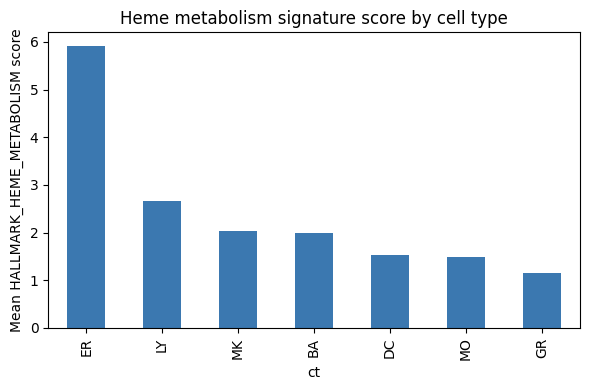

In [9]:
sig_scores = adata.obsm["vision_signatures"]
heme_col = [c for c in sig_scores.columns if "HEME_METABOLISM" in c][0]

by_ct = pd.DataFrame({"ct": adata.obs["ct"].values, "score": sig_scores[heme_col].values})
means = by_ct.groupby("ct")["score"].mean().sort_values(ascending=False)
print(means)

fig, ax = plt.subplots(figsize=(6, 4))
means.plot.bar(ax=ax, color="#3b78b0")
ax.set_ylabel(f"Mean {heme_col} score")
ax.set_title("Heme metabolism signature score by cell type")
plt.tight_layout()
plt.show()


## 8 · Takeaways

- Both `ha.hs` (Hotspot-equivalent gene modules) and `ha.vs` (VISION
  signatures) ran on a standard, non-spatial droplet scRNA-seq dataset using
  a PCA-based neighbor graph — no physical coordinates anywhere in this
  notebook. Harreman and Vision are not spatial-only tools.
- `ha.vs.analyze_vision()` reused Harreman's existing neighbor graph instead
  of rebuilding one, avoiding both wasted computation and the
  `obsp["weights"]` key collision between the two modules.
- The Vision-Hotspot integration surfaced a biologically coherent result
  (a heme-metabolism-correlated gene module in a hematopoiesis dataset)
  without any manual curation — the two independently-derived views
  (per-cell signature scores vs. gene-gene co-expression modules) agree.
